# WP3 — Partie 7 : Semantic analysis patch per patch

**Idée :** passer chaque token de patch visible individuellement dans le MLP de projection, et demander à CLIP ce qu'il représente sémantiquement.

**Modèle utilisé :** `projection_aug_mlp_best.pt` (wp3_5 baseline, val_cos=0.9319)

**Pipeline :**
1. `image` → MAE (masquage 75%) → ~49 tokens de patches visible (dim 1024)
2. Chaque token → normalisation sur **stats patches individuels** → MLP baseline aug
3. → `z_proj` (dim 768) → similarité cosinus avec les 100 classs CLIP
4. → class prédite per patch : *"flamingo"*, *"water"*, ...

**Résultat :** une carte sémantique 14×14 — chaque patch visible est colorié selon la CLIP class top-1.

> **Note** : les stats de normalisation sont calculées sur des tokens de patches individuels (et non sur `z_full = moyenne des patches`) pour éviter un biais systématique vers une class dominante.

## 7.1 Loading des modèles

In [19]:
import os
import json
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from transformers import ViTImageProcessor, ViTMAEModel, CLIPProcessor, CLIPModel

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device : {DEVICE}')

MAE_PATH = './vit-mae-large' if os.path.exists('./vit-mae-large') else 'facebook/vit-mae-large'
CLIP_PATH = './clip-vit-large-patch14' if os.path.exists(
    './clip-vit-large-patch14') else 'openai/clip-vit-large-patch14'

mae_processor = ViTImageProcessor.from_pretrained(MAE_PATH)
mae_encoder = ViTMAEModel.from_pretrained(MAE_PATH).to(DEVICE)
mae_encoder.eval()

clip_model = CLIPModel.from_pretrained(CLIP_PATH).to(DEVICE)
clip_processor = CLIPProcessor.from_pretrained(CLIP_PATH)
clip_model.eval()

print('MAE et CLIP loadeds')


Device : cpu
MAE et CLIP loadeds


## 7.2 Loading du MLP entraîné

In [20]:
import random
from tqdm.auto import tqdm


class ProjectionMLP(nn.Module):
    def __init__(self, in_dim=1024, hidden_dim=1024, out_dim=768):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.GELU(),
            nn.LayerNorm(hidden_dim),
            nn.Linear(hidden_dim, out_dim),
        )

    def forward(self, x):
        return F.normalize(self.net(x), dim=-1)


mlp = ProjectionMLP().to(DEVICE)
mlp.load_state_dict(torch.load('projection_aug_mlp_best.pt', map_location=DEVICE, weights_only=False))
mlp.eval()

# Stats calculées sur tokens de patches individuels (pas z_full)
PATCH_STATS_FILE = 'z_patch_norm_stats.pt'
if os.path.exists(PATCH_STATS_FILE):
    patch_stats = torch.load(PATCH_STATS_FILE, weights_only=False)
    z_patch_mean = patch_stats['mean']
    z_patch_std = patch_stats['std']
    print(f'Patch stats loaded : mean={z_patch_mean.mean():.4f}, std={z_patch_std.mean():.4f}')
else:
    from datasets import load_dataset
    train_raw = load_dataset('parquet', data_files={'train': './imagenet100-hf/data/train-*.parquet'})['train']
    N_STAT = 2000
    idxs = random.sample(range(len(train_raw)), N_STAT)
    tokens_list = []
    for i in tqdm(idxs, desc='Computing individual patch stats'):
        img = train_raw[i]['image'].convert('RGB')
        inp = mae_processor(images=img, return_tensors='pt')
        inp = {k: v.to(DEVICE) for k, v in inp.items()}
        g = torch.Generator()
        g.manual_seed(i % (2**31))
        noise = torch.rand(1, 196, generator=g).to(DEVICE)
        with torch.no_grad():
            out = mae_encoder(**inp, noise=noise)
        tokens_list.append(out.last_hidden_state[0, 1:].cpu())  # (49, 1024)
    all_tokens = torch.cat(tokens_list)                        # (N*49, 1024)
    z_patch_mean = all_tokens.mean(0)
    z_patch_std = all_tokens.std(0).clamp(min=1e-6)
    torch.save({'mean': z_patch_mean, 'std': z_patch_std}, PATCH_STATS_FILE)
    print(f'Stats calculées sur {all_tokens.shape[0]:,} tokens de patches individuels')
    print(f'mean={z_patch_mean.mean():.4f}, std={z_patch_std.mean():.4f}')


Patch stats loaded : mean=-0.0138, std=0.3019


## 7.3 Préparation des descriptions textuelles CLIP (100 classs)

In [21]:
with open('imagenet100-hf/label2text.json') as f:
    label2text = json.load(f)

class_names = list(label2text.values())          # ['bittern', 'conch', ...]
concepts = [f'a photo of a {n}' for n in class_names]

text_inputs = clip_processor(text=concepts, return_tensors='pt', padding=True).to(DEVICE)
with torch.no_grad():
    text_out = clip_model.text_model(**text_inputs)
    text_features = clip_model.text_projection(text_out.pooler_output)
text_features = F.normalize(text_features.float(), dim=-1)

print(f'{len(class_names)} classs encodées')
print('Exemples :', class_names[:5])


100 classs encodées
Exemples : ['bittern', 'conch', 'indigo bunting', 'hornbill', 'bee eater']


## 7.4 Fonction d'analyse d'une image

Pour une image donnée :
1. MAE encode avec masquage aléatoire 75% → 49 tokens de patches visible
2. Chaque token est normalisé avec les **stats patches individuels** (`z_patch_mean` / `z_patch_std`) → MLP → espace CLIP (768)
3. Similarité cosinus avec les 100 classs CLIP → top-1 per patch
4. Visualisation en 3 panels :
   - **Original image**
   - **Masked image** : pixels originaux sur les patches visible, gris sur les masked patches
   - **Semantic overlay** : image maskede + couleur semi-transparente par CLIP class top-1

In [22]:
def analyze_patches(image_pil, seed=42, top_k=3):
    """
    Semantic analysis patch per patch d'une image PIL.
    Returns :
      - patch_results : liste de dicts {patch_id, row, col, top_classs, top_sims}
      - mask          : Tensor (196,) — 0=visible, 1=masked (ordre raster)
      - ids_restore   : Tensor (196,)
    """
    g = torch.Generator()
    g.manual_seed(seed)
    noise = torch.rand(1, 196, generator=g).to(DEVICE)

    inputs = mae_processor(images=image_pil, return_tensors='pt')
    inputs = {k: v.to(DEVICE) for k, v in inputs.items()}

    with torch.no_grad():
        out = mae_encoder(**inputs, noise=noise)

    patch_tokens = out.last_hidden_state[0, 1:]   # (49, 1024) — exclut CLS
    mask = out.mask[0]                     # (196,) 0=visible, 1=masked
    ids_restore = out.ids_restore[0]              # (196,)

    ids_shuffle = torch.argsort(ids_restore)
    len_keep = (mask == 0).sum().item()
    visible_positions = ids_shuffle[:len_keep]

    # Normalisation sur stats patches individuels
    patch_norm = (patch_tokens.cpu() - z_patch_mean) / z_patch_std
    with torch.no_grad():
        z_proj = mlp(patch_norm.to(DEVICE))

    sims = z_proj @ text_features.T               # (49, 100)
    sims = sims - sims.mean(dim=-1, keepdim=True)  # centrage : retire le biais global

    patch_results = []
    for i in range(patch_tokens.shape[0]):
        orig_idx = visible_positions[i].item()
        row, col = orig_idx // 14, orig_idx % 14
        top_idx = sims[i].topk(top_k).indices.tolist()
        top_sims = sims[i].topk(top_k).values.tolist()
        patch_results.append({
            'patch_id':    orig_idx,
            'row':         row,
            'col':         col,
            'top_classs': [class_names[j] for j in top_idx],
            'top_sims':    top_sims,
        })

    return patch_results, mask, ids_restore


## 7.5 Visualisation : carte sémantique d'une image

In [23]:
PATCH_SIZE = 16  # ViT-L/16 → patches 16×16 sur une image 224×224


def make_masked_image(image_pil, mask):
    """
    Returns un np.array (224, 224, 3) uint8 :
    - patches visible  → pixels originaux
    - patches maskeds   → gris (128)
    mask : Tensor (196,), 0=visible, 1=masked, dans l'ordre raster 14×14
    """
    img = np.array(image_pil.resize((224, 224))).copy()
    for idx in range(196):
        if mask[idx].item() == 1:
            r, c = idx // 14, idx % 14
            img[r * PATCH_SIZE:(r + 1) * PATCH_SIZE,
                c * PATCH_SIZE:(c + 1) * PATCH_SIZE] = 128
    return img


def make_semantic_overlay(image_pil, patch_results, mask):
    """
    Returns (overlay_np, class_list) :
    overlay_np : (224, 224, 3) uint8 — image maskede + couleur semi-transparente
                 sur les patches visible selon leur CLIP class top-1
    class_list : liste ordonnée des classs présentes (pour la légende)
    """
    img_masked = make_masked_image(image_pil, mask).astype(float)

    class_list = []
    for p in patch_results:
        if p['top_classs'][0] not in class_list:
            class_list.append(p['top_classs'][0])

    overlay = img_masked.copy()
    for p in patch_results:
        ci = class_list.index(p['top_classs'][0])
        color = np.array(plt.cm.tab20.colors[ci % 20][:3]) * 255
        r, c = p['row'], p['col']
        region = overlay[r * PATCH_SIZE:(r + 1) * PATCH_SIZE,
                         c * PATCH_SIZE:(c + 1) * PATCH_SIZE]
        overlay[r * PATCH_SIZE:(r + 1) * PATCH_SIZE,
                c * PATCH_SIZE:(c + 1) * PATCH_SIZE] = 0.45 * region + 0.55 * color

    return overlay.clip(0, 255).astype(np.uint8), class_list


def plot_semantic_map(image_pil, patch_results, mask, true_label=None, seed=42):
    """
    3 panels :
      1. Original image
      2. Image maskede (patches maskeds en gris)
      3. Semantic overlay : image maskede + couleur par CLIP class top-1
    """
    img_masked = make_masked_image(image_pil, mask)
    overlay, class_list = make_semantic_overlay(image_pil, patch_results, mask)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    title = f'Patch-by-patch analysis — seed={seed}'
    if true_label:
        title += f'  |  class : {true_label}'
    fig.suptitle(title, fontsize=12)

    axes[0].imshow(image_pil.resize((224, 224)))
    axes[0].set_title('Original image')
    axes[0].axis('off')

    axes[1].imshow(img_masked)
    axes[1].set_title(f'Image maskede ({(mask == 1).sum().item()} patches maskeds / 196)')
    axes[1].axis('off')

    axes[2].imshow(overlay)
    axes[2].set_title('Semantic overlay (CLIP top-1 class)')
    axes[2].axis('off')

    # légende
    legend_patches = [
        mpatches.Patch(color=plt.cm.tab20.colors[i % 20], label=class_list[i])
        for i in range(len(class_list))
    ]
    legend_patches.append(mpatches.Patch(color=(0.5, 0.5, 0.5), label='masked'))
    axes[2].legend(handles=legend_patches, bbox_to_anchor=(1.05, 1),
                   loc='upper left', fontsize=8)

    plt.tight_layout()
    plt.show()


def print_patch_details(patch_results, top_k=3):
    print(f'{"Pos":>8}  Top-{top_k} classs CLIP')
    print('-' * 60)
    for p in patch_results:
        pos = f'({p["row"]},{p["col"]})'
        tops = '  |  '.join(f'{c} ({s:.3f})' for c, s in zip(p['top_classs'], p['top_sims']))
        print(f'{pos:>8}  {tops}')


def summary_patches(patch_results, true_label=None, top_n=6):
    """Compact summary : distribution des classs top-1 sur les patches visible."""
    from collections import Counter
    n_total = len(patch_results)
    counts = Counter(p['top_classs'][0] for p in patch_results)
    best = max(patch_results, key=lambda p: p['top_sims'][0])

    print(f'Top classs predicted ({n_total} patches visible) :')
    print('─' * 48)
    for cls, cnt in counts.most_common(top_n):
        pct = 100 * cnt / n_total
        bar = '█' * int(pct / 3)
        mark = '  ✓' if cls == true_label else ''
        print(f'  {cls:<25} {bar:<15} {cnt:2d} patches ({pct:.0f}%){mark}')
    print('─' * 48)
    print(f'  Patch le plus confident : ({best["row"]},{best["col"]}) '
          f'{best["top_classs"][0]} ({best["top_sims"][0]:.3f})')
    if true_label:
        n_correct = counts.get(true_label, 0)
        print(f'  Patches → true class : {n_correct}/{n_total} ({100*n_correct/n_total:.0f}%)')


def plot_vote_chart(patch_results, true_label=None, ax=None):
    """Bar chart des votes top-1 par class."""
    from collections import Counter
    counts = Counter(p['top_classs'][0] for p in patch_results)
    top = counts.most_common(8)
    labels = [c for c, _ in top]
    values = [v for _, v in top]
    colors = ['#2ecc71' if l == true_label else '#3498db' for l in labels]

    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 3))
    ax.barh(labels[::-1], values[::-1], color=colors[::-1])
    ax.set_xlabel('Number of patches')
    ax.set_title('Top-1 vote distribution')
    if ax is None:
        plt.tight_layout()
        plt.show()


## 7.6 Test sur des images du val set

Images sélectionnées : [7980, 8009, 11584, 4051, 10800]

Image 7980 — true class : hen


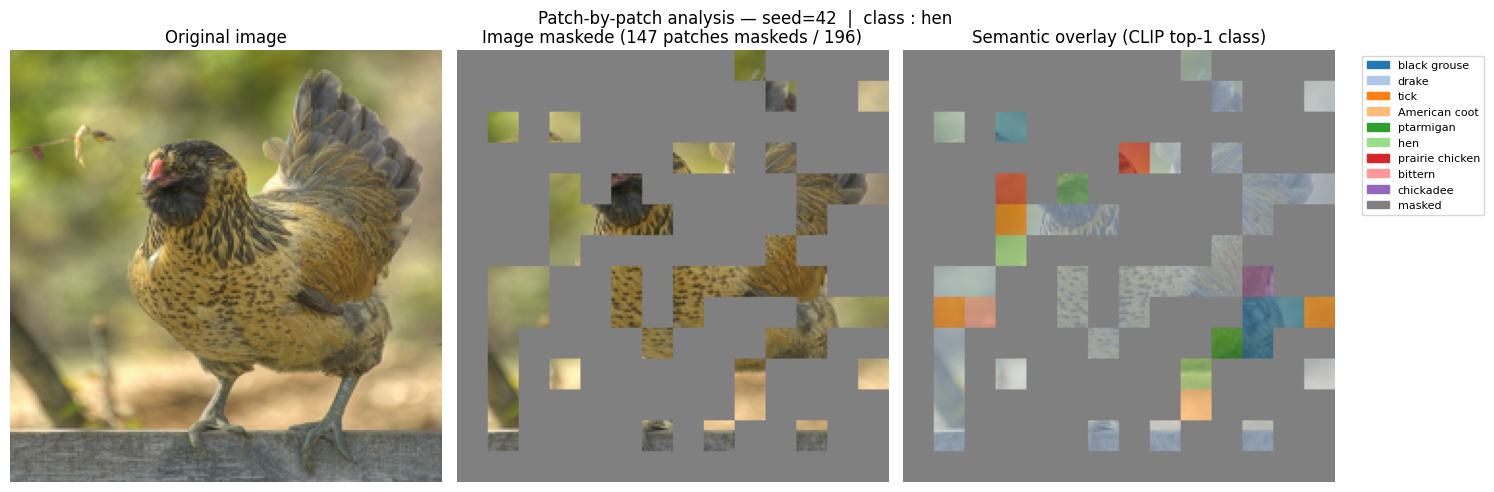

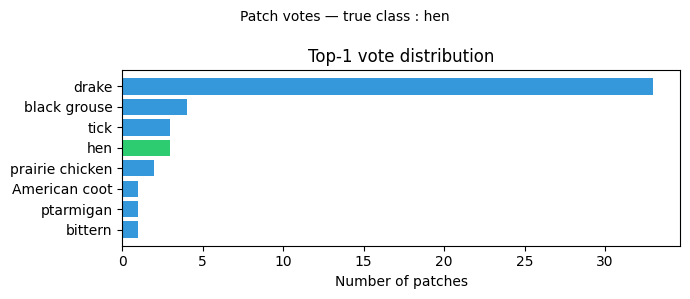

Top classs predicted (49 patches visible) :
────────────────────────────────────────────────
  drake                     ██████████████████████ 33 patches (67%)
  black grouse              ██               4 patches (8%)
  tick                      ██               3 patches (6%)
  hen                       ██               3 patches (6%)  ✓
  prairie chicken           █                2 patches (4%)
  American coot                              1 patches (2%)
────────────────────────────────────────────────
  Patch le plus confident : (4,3) prairie chicken (0.154)
  Patches → true class : 3/49 (6%)

Image 8009 — true class : thunder snake


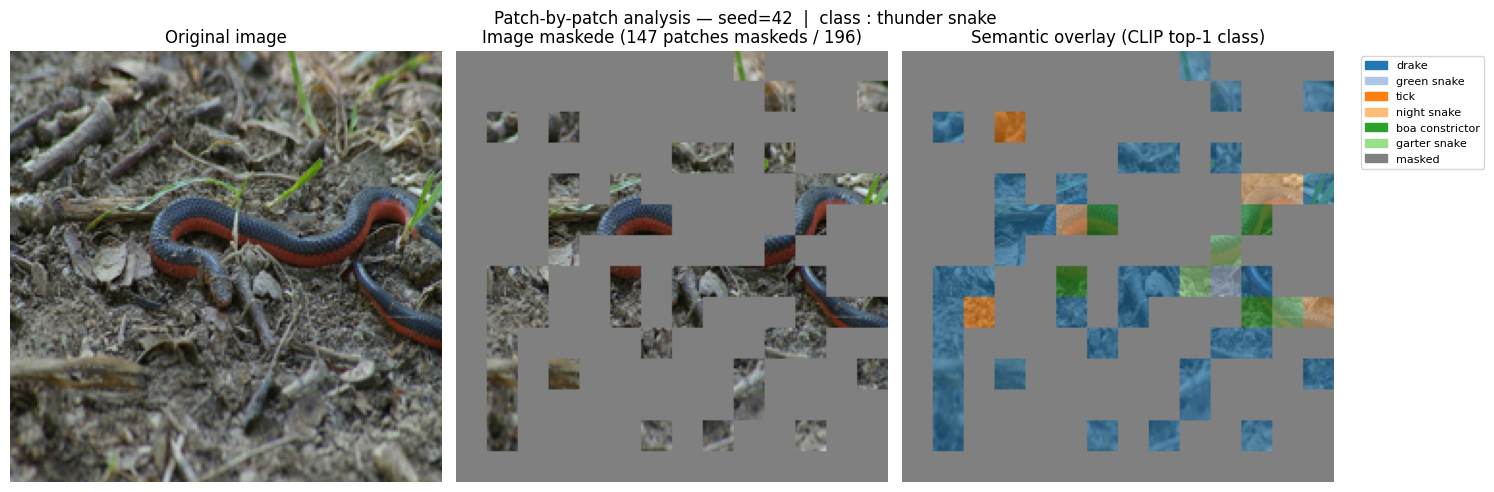

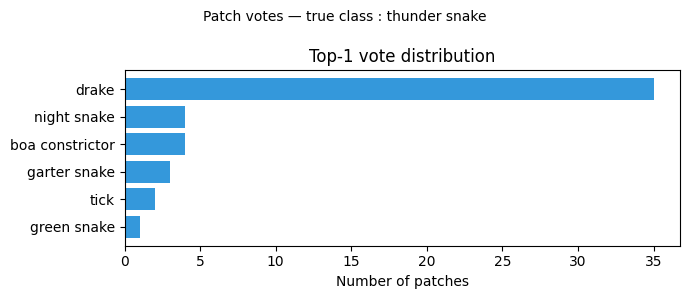

Top classs predicted (49 patches visible) :
────────────────────────────────────────────────
  drake                     ███████████████████████ 35 patches (71%)
  night snake               ██               4 patches (8%)
  boa constrictor           ██               4 patches (8%)
  garter snake              ██               3 patches (6%)
  tick                      █                2 patches (4%)
  green snake                                1 patches (2%)
────────────────────────────────────────────────
  Patch le plus confident : (8,12) garter snake (0.147)
  Patches → true class : 0/49 (0%)

Image 11584 — true class : pelican


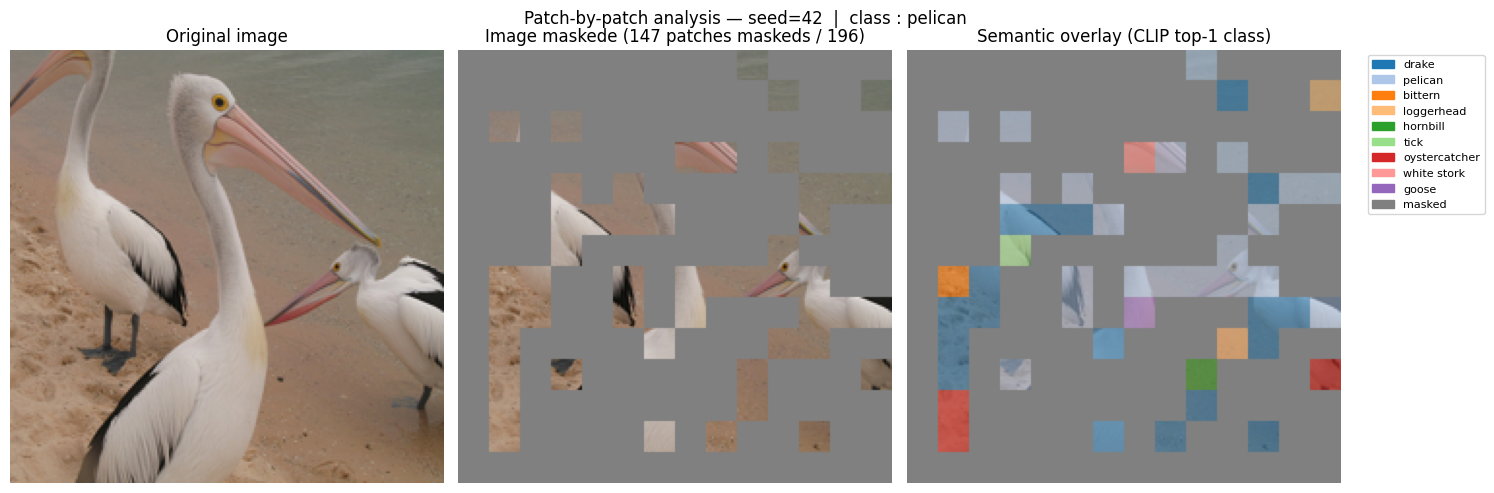

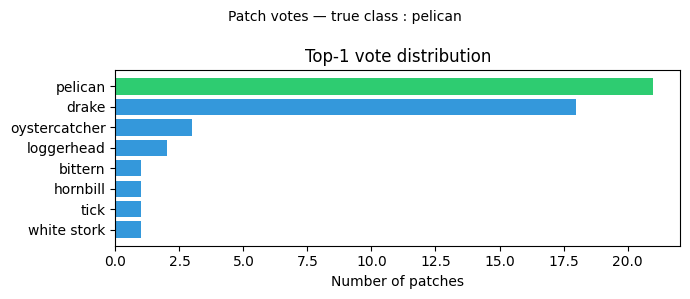

Top classs predicted (49 patches visible) :
────────────────────────────────────────────────
  pelican                   ██████████████  21 patches (43%)  ✓
  drake                     ████████████    18 patches (37%)
  oystercatcher             ██               3 patches (6%)
  loggerhead                █                2 patches (4%)
  bittern                                    1 patches (2%)
  hornbill                                   1 patches (2%)
────────────────────────────────────────────────
  Patch le plus confident : (7,2) drake (0.153)
  Patches → true class : 21/49 (43%)

Image 4051 — true class : goldfinch


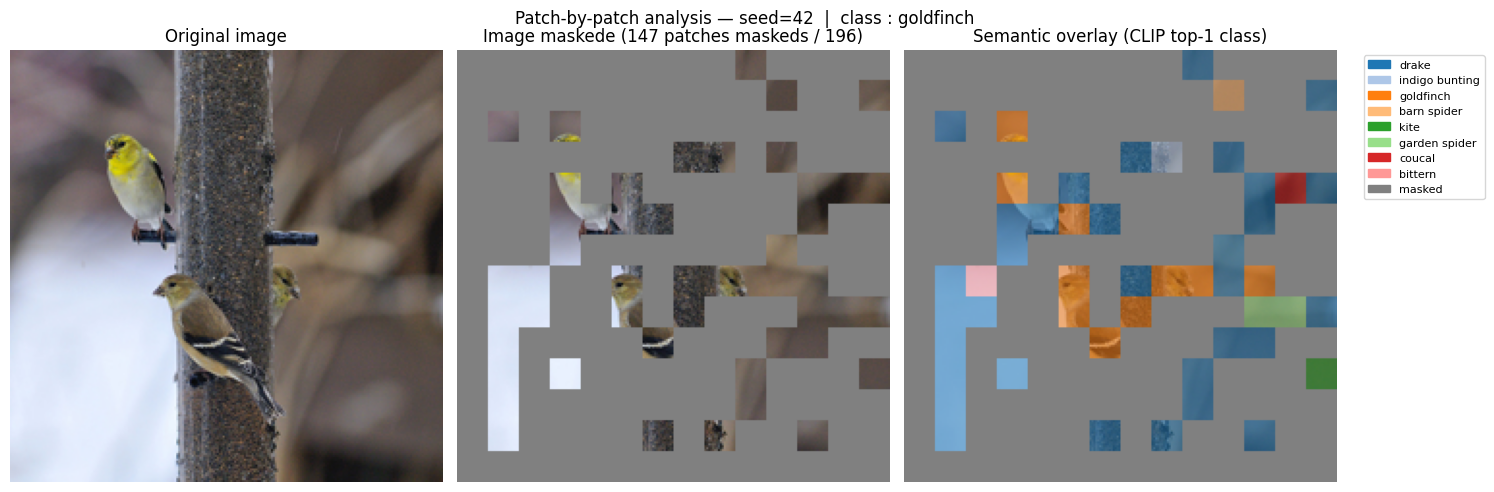

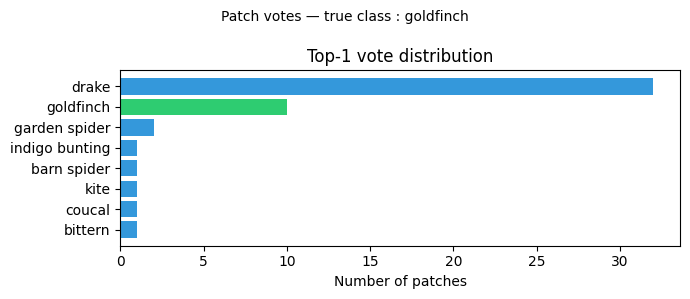

Top classs predicted (49 patches visible) :
────────────────────────────────────────────────
  drake                     █████████████████████ 32 patches (65%)
  goldfinch                 ██████          10 patches (20%)  ✓
  garden spider             █                2 patches (4%)
  indigo bunting                             1 patches (2%)
  barn spider                                1 patches (2%)
  kite                                       1 patches (2%)
────────────────────────────────────────────────
  Patch le plus confident : (7,8) goldfinch (0.231)
  Patches → true class : 10/49 (20%)

Image 10800 — true class : chiton


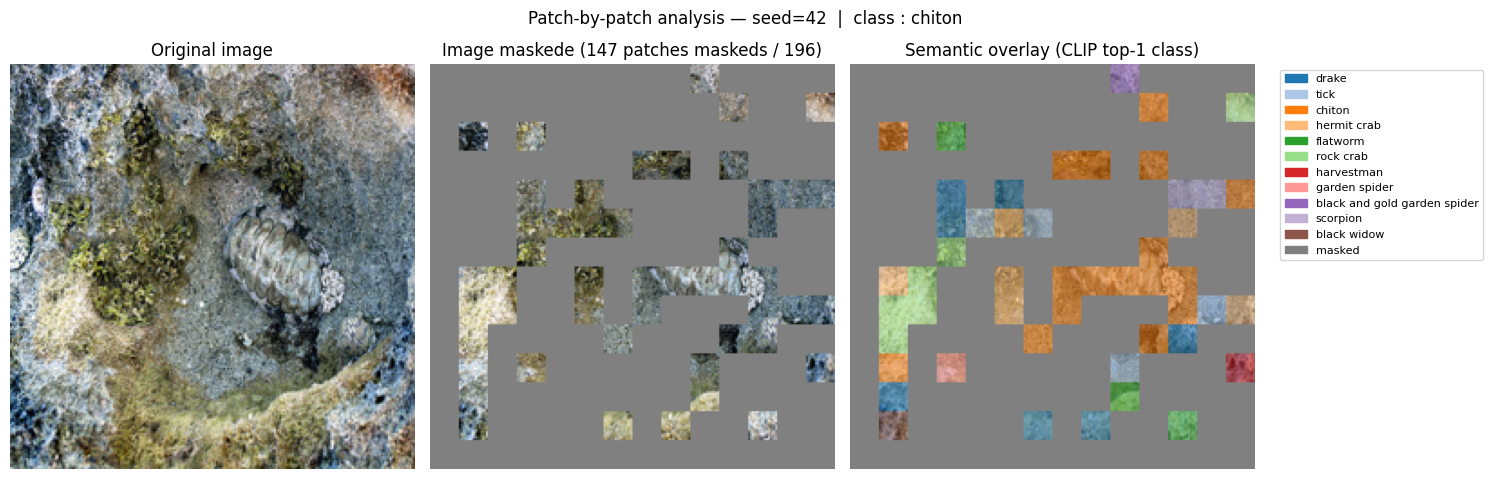

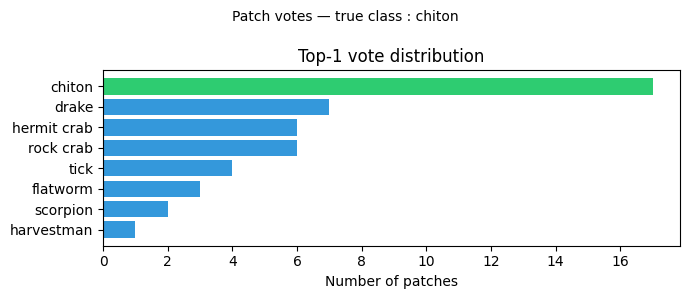

Top classs predicted (49 patches visible) :
────────────────────────────────────────────────
  chiton                    ███████████     17 patches (35%)  ✓
  drake                     ████             7 patches (14%)
  hermit crab               ████             6 patches (12%)
  rock crab                 ████             6 patches (12%)
  tick                      ██               4 patches (8%)
  flatworm                  ██               3 patches (6%)
────────────────────────────────────────────────
  Patch le plus confident : (9,1) rock crab (0.151)
  Patches → true class : 17/49 (35%)


In [24]:
import random
from datasets import load_dataset

DATASET_DIR = './imagenet100-hf'
pattern = f'{DATASET_DIR}/data/validation-*.parquet'
val_ds_raw = load_dataset('parquet', data_files={'validation': pattern})['validation']

N_IMAGES = 5
INDICES = random.sample(range(len(val_ds_raw)), N_IMAGES)
print(f'Images sélectionnées : {INDICES}')

for idx in INDICES:
    image_pil = val_ds_raw[idx]['image'].convert('RGB')
    true_label = label2text[str(val_ds_raw[idx]['label'])]

    patch_results, mask, _ = analyze_patches(image_pil, seed=42)

    print(f'\n{"="*55}')
    print(f'Image {idx} — true class : {true_label}')

    plot_semantic_map(image_pil, patch_results, mask, true_label=true_label)

    fig, ax = plt.subplots(figsize=(7, 3))
    fig.suptitle(f'Patch votes — true class : {true_label}', fontsize=10)
    plot_vote_chart(patch_results, true_label=true_label, ax=ax)
    plt.tight_layout()
    plt.show()

    summary_patches(patch_results, true_label=true_label)


## 7.7 Comparaison : même image, masques different

Est-ce que les patches d'une même zone donnent la même CLIP class selon le masque ?

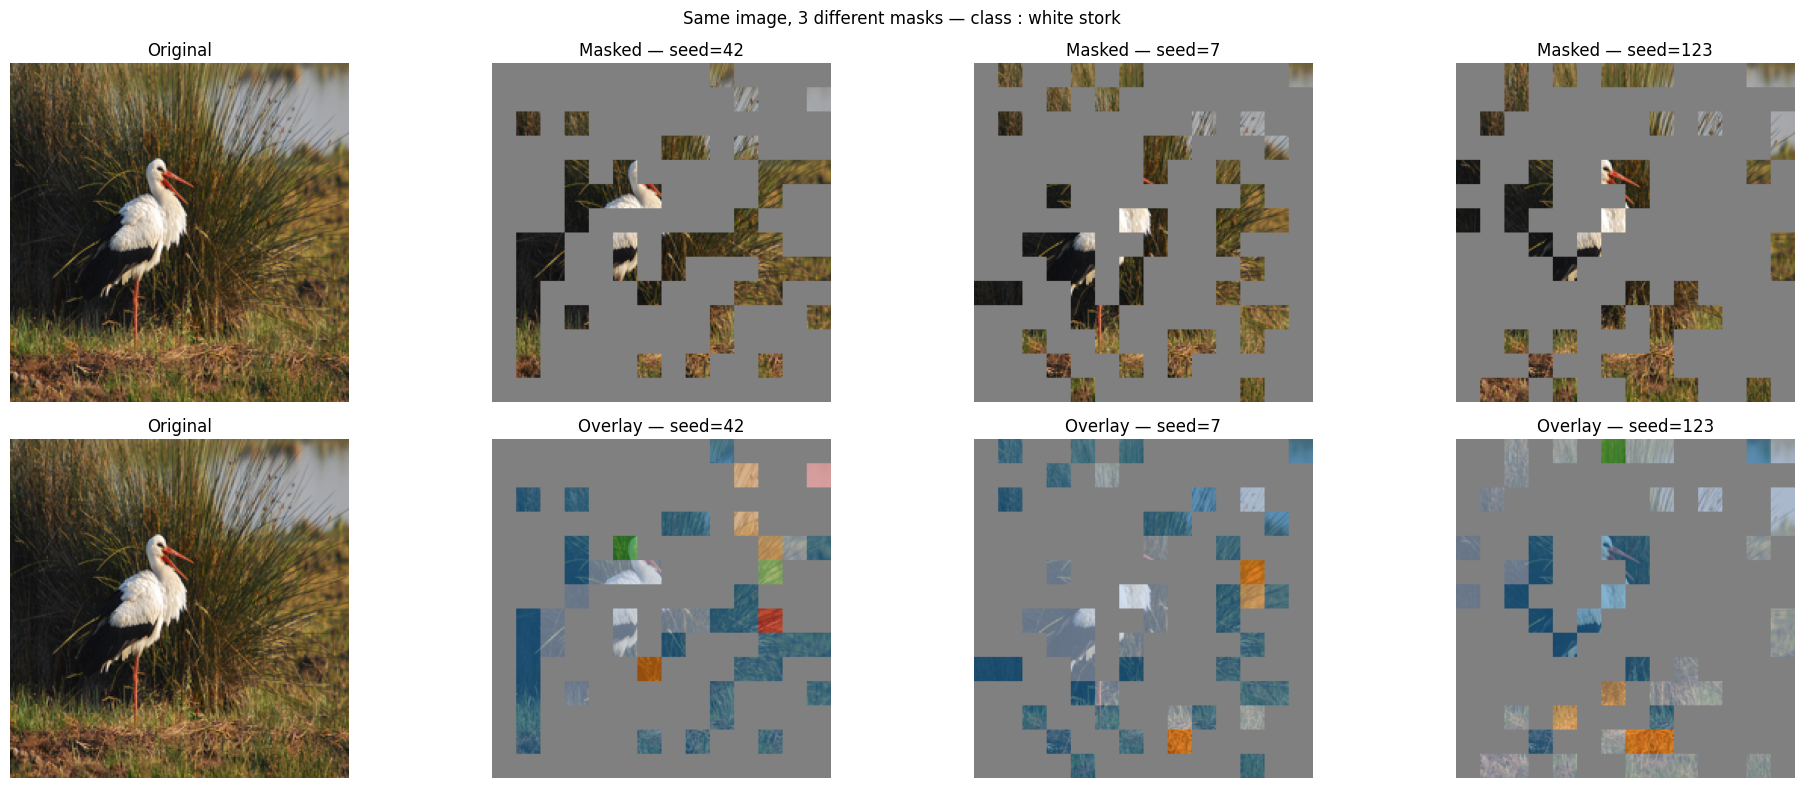

In [39]:
image_pil = val_ds_raw[0]['image'].convert('RGB')
true_label = label2text[str(val_ds_raw[0]['label'])]

seeds = [42, 7, 123]
fig, axes = plt.subplots(2, len(seeds) + 1, figsize=(20, 8))
fig.suptitle(f'Same image, 3 different masks — class : {true_label}', fontsize=12)

# colonne 0 : image originale
for row in range(2):
    axes[row][0].imshow(image_pil.resize((224, 224)))
    axes[row][0].set_title('Original')
    axes[row][0].axis('off')

for col, seed in enumerate(seeds, start=1):
    patch_results, mask, _ = analyze_patches(image_pil, seed=seed)
    img_masked = make_masked_image(image_pil, mask)
    overlay, class_list = make_semantic_overlay(image_pil, patch_results, mask)

    axes[0][col].imshow(img_masked)
    axes[0][col].set_title(f'Masked — seed={seed}')
    axes[0][col].axis('off')

    axes[1][col].imshow(overlay)
    axes[1][col].set_title(f'Overlay — seed={seed}')
    axes[1][col].axis('off')

plt.tight_layout()
plt.show()


## 7.8 Cohérence patch vs image entière

Pour chaque image : est-ce que la class prédite par le **patch le plus confident** correspond à la class prédite par **z_full** ?

In [38]:
# Charger les paires val augmentées (z_full masked = moyenne 49 patches visible)
data_val = torch.load('pairs_aug_K5_val.pt', weights_only=False)

norm_stats = torch.load('z_aug_K5_norm_stats.pt', weights_only=False)
z_mean_train = norm_stats['mean']
z_std_train = norm_stats['std']

N = 50
match_full_vs_best_patch = 0
match_full_vs_true = 0

for i in range(N):
    # Prédiction via z_full masked
    z_full = data_val['z_full'][i]
    z_norm = (z_full - z_mean_train) / z_std_train
    with torch.no_grad():
        z_proj_full = mlp(z_norm.unsqueeze(0).to(DEVICE))
    pred_full_idx = (z_proj_full @ text_features.T).argmax().item()
    pred_full = class_names[pred_full_idx]

    # Prédiction via patch le plus confident
    image_pil = val_ds_raw[i]['image'].convert('RGB')
    true_label = label2text[str(val_ds_raw[i]['label'])]
    patch_results, _, _ = analyze_patches(image_pil, seed=42)

    best_patch = max(patch_results, key=lambda p: p['top_sims'][0])
    pred_patch = best_patch['top_classs'][0]

    if pred_full == pred_patch:
        match_full_vs_best_patch += 1
    if pred_full == true_label:
        match_full_vs_true += 1

print(f'Sur {N} images :')
print(f'  z_full masked top-1 correct : {match_full_vs_true}/{N}  ({100*match_full_vs_true/N:.1f}%)')
print(
    f'  z_full masked == meilleur patch top-1  : {match_full_vs_best_patch}/{N}  ({100*match_full_vs_best_patch/N:.1f}%)')


Sur 50 images :
  z_full masked top-1 correct : 34/50  (68.0%)
  z_full masked == meilleur patch top-1  : 23/50  (46.0%)
